Ejercicio 1 – Recorte de imagenP.jpg

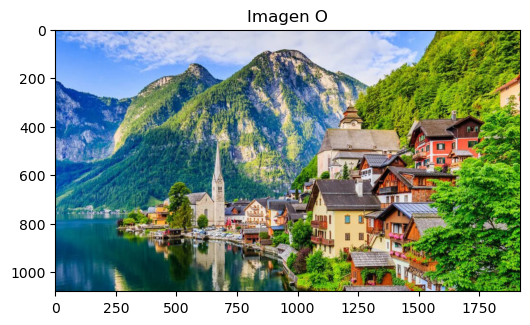

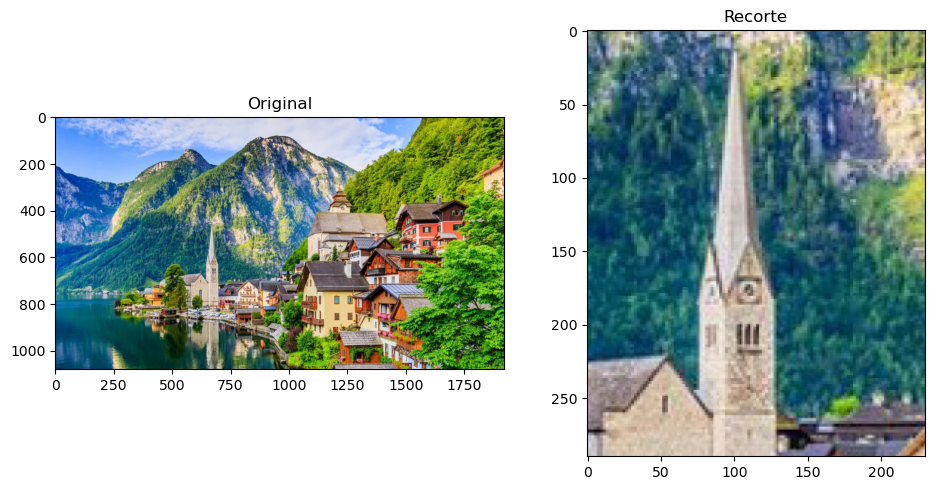

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_bgr = cv2.imread('imagenP.jpg')

img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title('Imagen O')
plt.axis('on')  
plt.show()

# AJUSTAMoS ESTOS VALORES A OJO XD
y1, y2 = 450, 740   # f
x1, x2 = 570, 800   # c

recorte = img[y1:y2, x1:x2, :] 

# Guardar recorte
recorte_bgr = cv2.cvtColor(recorte, cv2.COLOR_RGB2BGR)
cv2.imwrite('imagenP_recorte.jpg', recorte_bgr)

# Mostrar original y recortada
fig, axs = plt.subplots(1, 2, figsize=(10,5))

axs[0].imshow(img)
axs[0].set_title('Original')
axs[0].axis('on')

axs[1].imshow(recorte)
axs[1].set_title('Recorte')
axs[1].axis('on')

plt.tight_layout()
plt.show()


Ejercicio 2 – Degradado lineal a colores

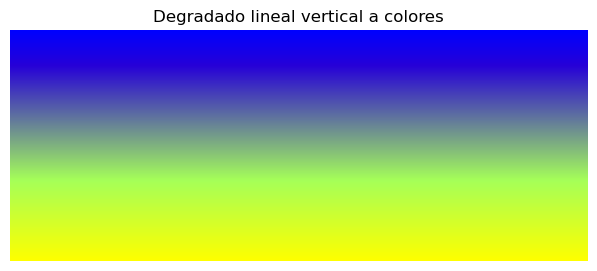

In [32]:
import numpy as np
import matplotlib.pyplot as plt

alto = 200
ancho = 500

y = np.linspace(0, 1, alto)       
grad_col = y.reshape(alto, 1)     

grad = np.repeat(grad_col, ancho, axis=1)

R = (grad * 255)
G = (np.clip(grad * 2 - 0.3, 0, 1) * 255)
B = ((1 - grad) * 255)

imagen_grad = np.dstack([R, G, B]).astype(np.uint8)  

plt.figure(figsize=(8,3))
plt.imshow(imagen_grad)
plt.title('Degradado lineal vertical a colores')
plt.axis('off')
plt.show()

plt.imsave('degradado_colores_vertical.png', imagen_grad)


Ejercicio 3 – Tablero de ajedrez (casilla 100×100)

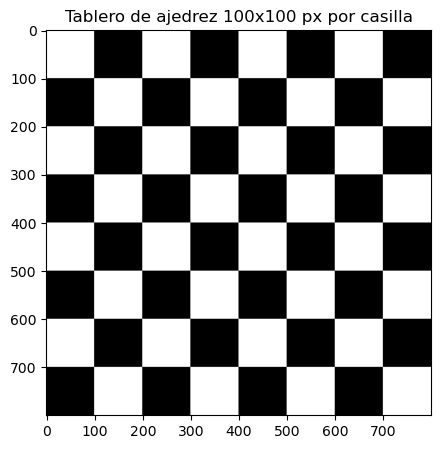

In [33]:
import numpy as np
import matplotlib.pyplot as plt

lado_casilla = 100
num_casillas = 8  # 8x8
alto = lado_casilla * num_casillas
ancho = alto

tablero = np.zeros((alto, ancho), dtype=np.uint8)  # gris

for i in range(num_casillas):
    for j in range(num_casillas):
        if (i + j) % 2 == 0: 
            y1 = i * lado_casilla
            y2 = (i + 1) * lado_casilla
            x1 = j * lado_casilla
            x2 = (j + 1) * lado_casilla
            tablero[y1:y2, x1:x2] = 255

plt.figure(figsize=(5,5))
plt.imshow(tablero, cmap='gray')
plt.title('Tablero de ajedrez 100x100 px por casilla')
plt.axis('on')
plt.show()

# Guardar
plt.imsave('tablero_ajedrez.png', tablero, cmap='gray')


Ejercicio 4 – Posterización, solarización y falso color

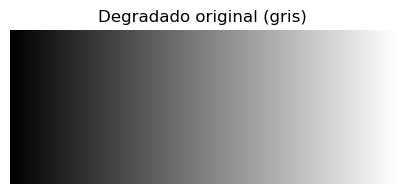

In [20]:
import numpy as np
import matplotlib.pyplot as plt

grad_gray = imagen_grad[:, :, 0] 

plt.figure(figsize=(6,2))
plt.imshow(grad_gray, cmap='gray')
plt.title('Degradado original (gris)')
plt.axis('off')
plt.show()


Posterización

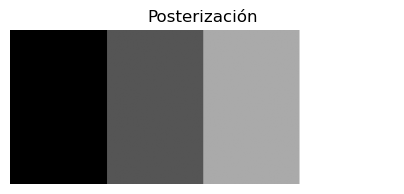

In [21]:
niveles = 4
paso = 256 // niveles

poster = (grad_gray // paso) * paso  

plt.figure(figsize=(6,2))
plt.imshow(poster, cmap='gray')
plt.title('Posterización')
plt.axis('off')
plt.show()

plt.imsave('degradado_posterizado.png', poster, cmap='gray')


Solarización

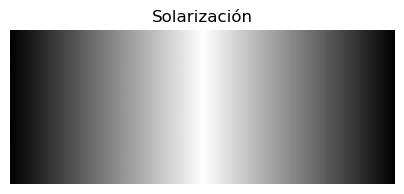

In [22]:
umbral = 128

solar = np.where(grad_gray > umbral, 255 - grad_gray, grad_gray).astype(np.uint8)

plt.figure(figsize=(6,2))
plt.imshow(solar, cmap='gray')
plt.title('Solarización')
plt.axis('off')
plt.show()

plt.imsave('degradado_solarizado.png', solar, cmap='gray')


Paletas de falso color

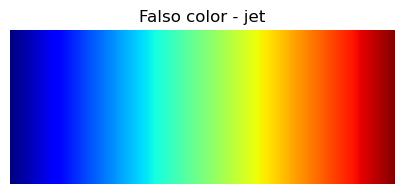

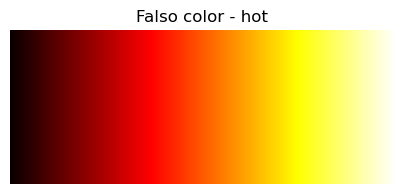

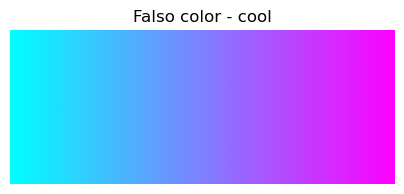

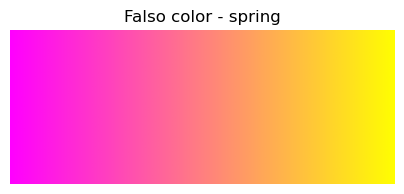

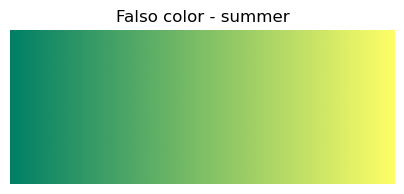

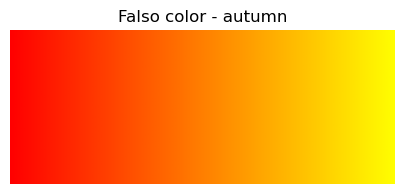

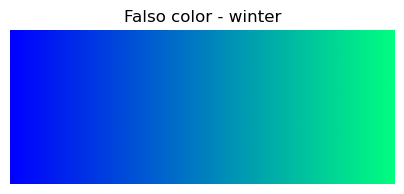

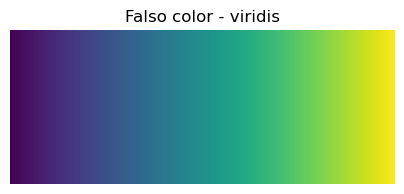

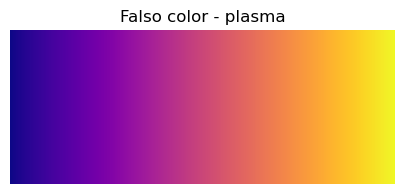

In [23]:
colormaps = [
    'jet', 'hot', 'cool', 'spring', 'summer', 'autumn', 'winter', 'viridis', 'plasma'
]

for cmap in colormaps:
    plt.figure(figsize=(6,2))
    plt.imshow(grad_gray, cmap=cmap)
    plt.title('Falso color - ' + cmap)
    plt.axis('off')
    plt.show()

    nombre_archivo = f'degradado_falso_color_{cmap}.png'
    plt.imsave(nombre_archivo, grad_gray, cmap=cmap)


Ejercicio 5 – Degradado lineal aplicado a imagen1.jpg

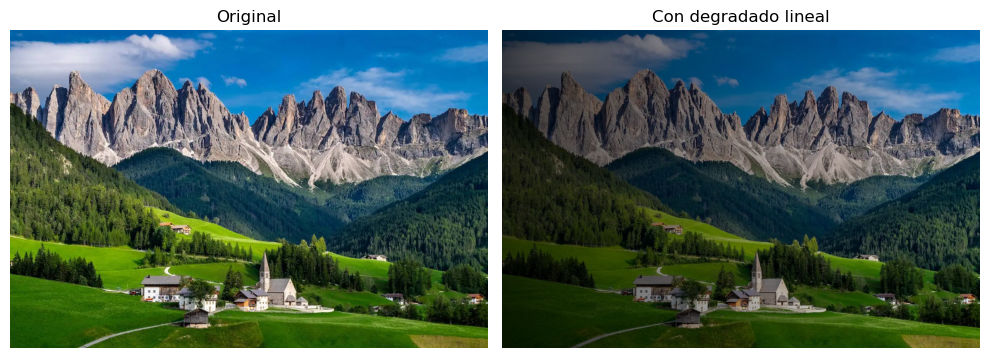

True

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img1_bgr = cv2.imread('imagen1.jpg')
img1 = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2RGB)

alto, ancho, _ = img1.shape

x = np.linspace(0.3, 1.0, ancho)
grad = np.ones((alto, 1)) * x         
grad_rgb = np.dstack([grad, grad, grad])  

img1_float = img1.astype(np.float32) / 255.0
aplicada = img1_float * grad_rgb
aplicada = np.clip(aplicada, 0, 1)
aplicada8 = (aplicada * 255).astype(np.uint8)

fig, axs = plt.subplots(1, 2, figsize=(10,5))

axs[0].imshow(img1)
axs[0].set_title('Original')
axs[0].axis('off')

axs[1].imshow(aplicada8)
axs[1].set_title('Con degradado lineal')
axs[1].axis('off')

plt.tight_layout()
plt.show()

# Guardar
aplicada_bgr = cv2.cvtColor(aplicada8, cv2.COLOR_RGB2BGR)
cv2.imwrite('imagen1_degradado.jpg', aplicada_bgr)


Ejercicio 6 – Imagen con cuadrados + filtro Bayer (todas las combinaciones)

1) Imagen original con solo cuadrados

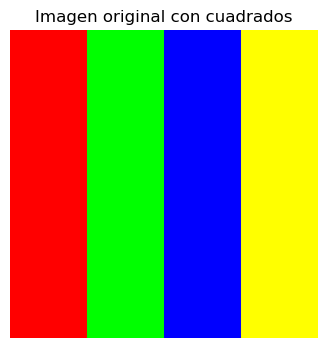

In [35]:
import numpy as np
import matplotlib.pyplot as plt

alto = 400
ancho = 400
img = np.zeros((alto, ancho, 3), dtype=np.uint8)

lado = 100  
colores = [
    [255, 0, 0],   # rojo
    [0, 255, 0],   # verde
    [0, 0, 255],   # azul
    [255, 255, 0], # amarillo
]

idx_color = 0
for i in range(0, alto, lado):
    for j in range(0, ancho, lado):
        color = colores[idx_color % len(colores)]
        img[i:i+lado, j:j+lado, :] = color
        idx_color += 1

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title('Imagen original con cuadrados')
plt.axis('off')
plt.show()

# Guardar
plt.imsave('cuadrados_original.png', img)


2) Función para aplicar mosaico Bayer (1 canal y color)

In [ ]:
def mosaico_bayer(img_rgb, patron='RGGB'):
    h, w, _ = img_rgb.shape
    bayerrg = np.zeros((h, w), dtype=np.uint8)
    bayercolor = np.zeros((h, w, 3), dtype=np.uint8)

    for i in range(h):
        for j in range(w):
        
            ip = i % 2
            jp = j % 2

            
            if patron == 'RGGB':
                # R G
                # G B
                if ip == 0 and jp == 0:   # R
                    val = img_rgb[i, j, 0]
                    canal = 0
                elif ip == 0 and jp == 1: # G
                    val = img_rgb[i, j, 1]
                    canal = 1
                elif ip == 1 and jp == 0: # G
                    val = img_rgb[i, j, 1]
                    canal = 1
                else:                     # B
                    val = img_rgb[i, j, 2]
                    canal = 2

            elif patron == 'BGGR':
                # B G
                # G R
                if ip == 0 and jp == 0:   # B
                    val = img_rgb[i, j, 2]
                    canal = 2
                elif ip == 0 and jp == 1: # G
                    val = img_rgb[i, j, 1]
                    canal = 1
                elif ip == 1 and jp == 0: # G
                    val = img_rgb[i, j, 1]
                    canal = 1
                else:                     # R
                    val = img_rgb[i, j, 0]
                    canal = 0

            elif patron == 'GRBG':
                # G R
                # B G
                if ip == 0 and jp == 0:   # G
                    val = img_rgb[i, j, 1]
                    canal = 1
                elif ip == 0 and jp == 1: # R
                    val = img_rgb[i, j, 0]
                    canal = 0
                elif ip == 1 and jp == 0: # B
                    val = img_rgb[i, j, 2]
                    canal = 2
                else:                     # G
                    val = img_rgb[i, j, 1]
                    canal = 1

            elif patron == 'GBRG':
                # G B
                # R G
                if ip == 0 and jp == 0:   # G
                    val = img_rgb[i, j, 1]
                    canal = 1
                elif ip == 0 and jp == 1: # B
                    val = img_rgb[i, j, 2]
                    canal = 2
                elif ip == 1 and jp == 0: # R
                    val = img_rgb[i, j, 0]
                    canal = 0
                else:                     # G
                    val = img_rgb[i, j, 1]
                    canal = 1

            bayerrg[i, j] = val
            bayercolor[i, j, canal] = val

    return bayerrg, bayercolor


3) Aplicar los 4 patrones y mostrar/guardar

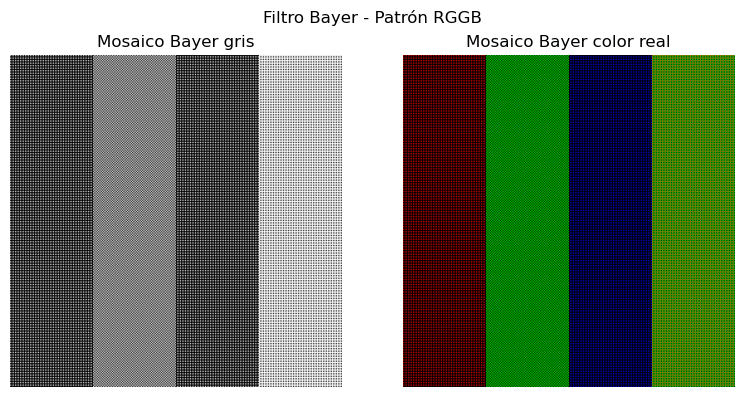

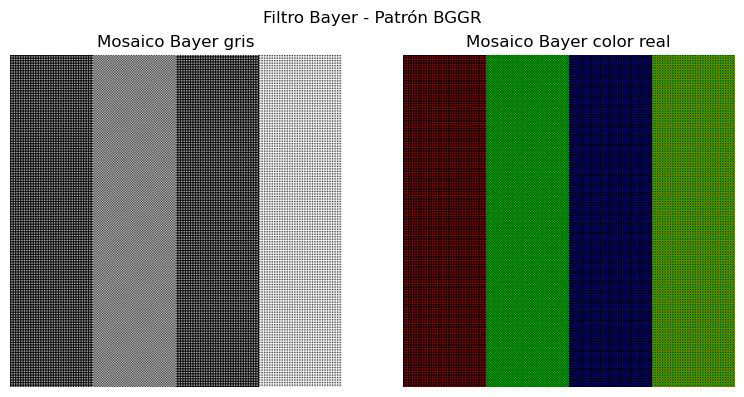

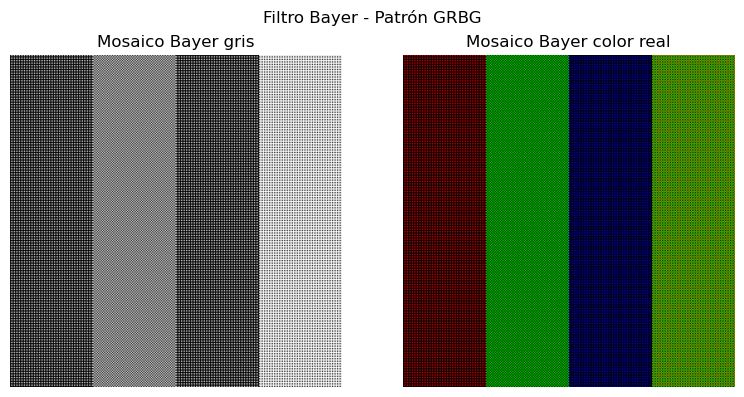

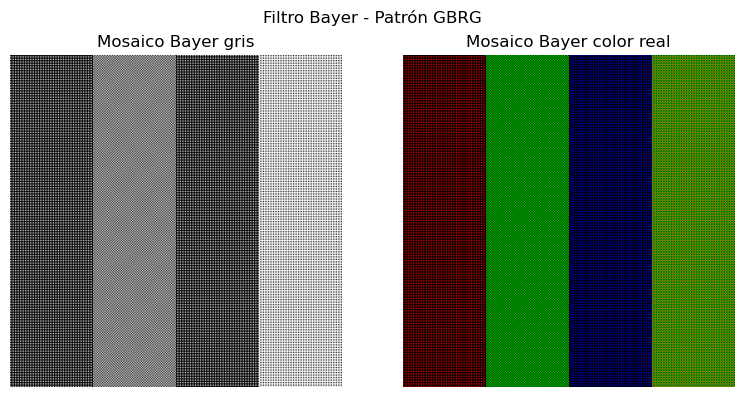

In [28]:
patrones = ['RGGB', 'BGGR', 'GRBG', 'GBRG']

for patron in patrones:
    bayerrg, bayercolor = mosaico_bayer(img, patron=patron)

    plt.figure(figsize=(8,4))
    plt.suptitle('Filtro Bayer - Patrón ' + patron)

    plt.subplot(1,2,1)
    plt.title('Mosaico Bayer gris')
    plt.imshow(bayerrg, cmap='gray')
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.title('Mosaico Bayer color real')
    plt.imshow(bayercolor)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Guardar resultados
    nombre_gris = f'cuadrados_bayer_{patron}_gris.png'
    nombre_color = f'cuadrados_bayer_{patron}_color.png'

    plt.imsave(nombre_gris, bayerrg, cmap='gray')
    plt.imsave(nombre_color, bayercolor)
